# Decision mechanics — ε-greedy propensity, DR gate, and what deploys before the shift

A process-level deep dive into the two decisions that happen **before and during** a rep's day:

| Phase | Question | Mechanism |
|-------|----------|-----------|
| **Pre-shift (offline)** | Which bandit policy do we deploy? | OPE + DR promotion gate on held-out logs |
| **At each door (online)** | What action do we take? | Bandit `recommend` → `(action, propensity)` |

We work through the math on **one door** and **one policy comparison**, then connect to `run_demo`.


In [1]:
import warnings
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

from nba.bandits.epsilon_greedy import EpsilonGreedy
from nba.bandits.thompson import BootstrapEnsemble, ThompsonSampling
from nba.bandits.ucb import UCB
from nba.config import Settings
from nba.data.simulator import frame_to_events
from nba.ope.estimators import LoggedBatch, eval_action_matrix, evaluate_all, q_matrix
from nba.ope.gate import PromotionGate
from nba.reward.model import RewardModel
from nba.schema import ACTIONS

warnings.filterwarnings("ignore", message="X does not have valid feature names")

SEED = 7
RNG = np.random.default_rng(SEED)
DATASET_MODE = "relational"
_logs = {"flat": "data/logs.parquet", "relational": "data/relational/logs.parquet"}[DATASET_MODE]
_models = {"flat": "artifacts/models", "relational": "artifacts/models/relational"}[DATASET_MODE]
DATA_PATH = next((p for p in (Path(_logs), Path("..") / _logs) if p.exists()), Path(_logs))
MODEL_DIR = next((p for p in (Path(_models), Path("..") / _models) if p.exists()), Path(_models))
settings = Settings(dataset_mode=DATASET_MODE, seed=SEED)

model = RewardModel.load(MODEL_DIR)
events = frame_to_events(pd.read_parquet(DATA_PATH))
ctx = events[RNG.integers(len(events))].context
print(f"loaded {len(events):,} events; demo door property_value={ctx.property_value:,}")


loaded 100,000 events; demo door property_value=189,450.05802341976


## Part A — ε-greedy: from q(x,a) to propensity p

For each action `a`, the reward model outputs `q(x,a)`. ε-greedy builds a **full-support** distribution:

- Every arm gets explore mass: `ε / |A|`
- The exploit mass `1 − ε` goes to the argmax arm(s) (split uniformly on ties)

Then `recommend` **samples** one arm; the returned **propensity** is the probability of that draw.


In [2]:
eps = settings.epsilon
policy = EpsilonGreedy(model, epsilon=eps, rng=RNG)

q = model.q_all(ctx)
dist = policy.action_dist(ctx)

table = pd.DataFrame(
    {
        "action": [a.value for a in ACTIONS],
        "q(x,a)": [round(float(v), 4) for v in q],
        "pi(a|x)": [round(dist[a], 4) for a in ACTIONS],
    }
)
best = q.argmax()
explore_each = eps / len(ACTIONS)
exploit_each = (1 - eps) / int((q == q.max()).sum())
print(f"epsilon = {eps}   |A| = {len(ACTIONS)}")
print(f"explore mass per arm = eps/|A| = {explore_each:.4f}")
print(f"exploit mass on argmax tie(s) = (1-eps)/n_best = {exploit_each:.4f}")
print(table.to_string(index=False))

# Sample several recommends — propensity equals dist[action] for the chosen arm
samples = [policy.recommend(ctx) for _ in range(5)]
print("\nsample draws (action, propensity):")
for a, p in samples:
    print(f"  {a.value:16s}  p={p:.4f}  (matches pi={dist[a]:.4f})")


epsilon = 0.1   |A| = 5
explore mass per arm = eps/|A| = 0.0200
exploit mass on argmax tie(s) = (1-eps)/n_best = 0.4500
        action  q(x,a)  pi(a|x)
     knock_now  0.1180     0.02
   leave_flyer  0.1248     0.02
     skip_door -0.0000     0.02
   pitch_solar  0.1626     0.47
pitch_security  0.1626     0.47

sample draws (action, propensity):
  pitch_security    p=0.4700  (matches pi=0.4700)
  pitch_security    p=0.4700  (matches pi=0.4700)
  pitch_solar       p=0.4700  (matches pi=0.4700)
  pitch_solar       p=0.4700  (matches pi=0.4700)
  pitch_security    p=0.4700  (matches pi=0.4700)


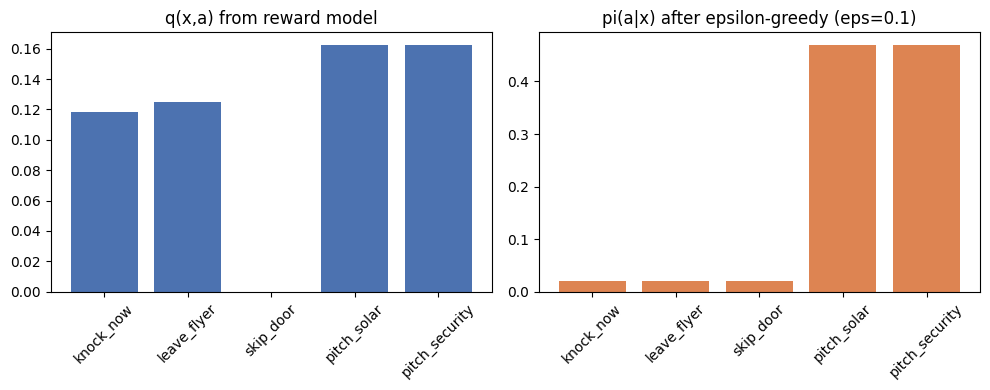

In [3]:
# Visual: q vs pi — exploration flattens the peak
fig, axes = plt.subplots(1, 2, figsize=(10, 4))
labels = [a.value for a in ACTIONS]
axes[0].bar(labels, q, color="#4C72B0")
axes[0].set_title("q(x,a) from reward model")
axes[0].tick_params(axis="x", rotation=45)
axes[1].bar(labels, [dist[a] for a in ACTIONS], color="#DD8452")
axes[1].set_title(f"pi(a|x) after epsilon-greedy (eps={eps})")
axes[1].tick_params(axis="x", rotation=45)
plt.tight_layout()
plt.show()


## Part B — How door_profit connects routing to the bandit

Routing does **not** pick an action. It uses the **same** `action_dist` to price the door:

`door_profit(x) = Σ_a pi(a|x) · q(x,a)`

So exploration mass on a high-q arm lowers the price vs greedy argmax — but the route reflects what the
policy will actually do in the field.


In [4]:
import tempfile

from nba.api.store import EventStore
from nba.pipeline.orchestrator import Orchestrator
from nba.routing.distance import HaversineEngine

tmp = Path(tempfile.mkdtemp()) / "e.db"
orch = Orchestrator(
    policy=policy,
    reward_model=model,
    distance_engine=HaversineEngine(speed_kmh=settings.walking_speed_kmh),
    store=EventStore(tmp),
    settings=Settings(db_path=tmp, seed=SEED),
)
orch_greedy = Orchestrator(
    policy=policy,
    reward_model=model,
    distance_engine=HaversineEngine(speed_kmh=settings.walking_speed_kmh),
    store=EventStore(tmp),
    settings=Settings(db_path=tmp, seed=SEED),
    argmax_profit=True,
)
weighted = orch.door_profit(ctx)
greedy = orch_greedy.door_profit(ctx)
manual = float(sum(dist[a] * float(q[i]) for i, a in enumerate(ACTIONS)))
print(f"door_profit (bandit-weighted) = {weighted:.4f}")
print(f"door_profit (argmax q)        = {greedy:.4f}")
print(f"manual Σ pi·q                 = {manual:.4f}")
print(f"exploration tax               = {greedy - weighted:.4f}  (weighted ≤ greedy)")


door_profit (bandit-weighted) = 0.1577
door_profit (argmax q)        = 0.1626
manual Σ pi·q                 = 0.1577
exploration tax               = 0.0049  (weighted ≤ greedy)


## Part C — DR gate: which policy deploys before the shift?

`run_demo` holds out 20% of logs, fits the model on the rest, then scores ε-greedy / UCB / Thompson
**off-policy** on the held-out batch. The **promotion gate** uses the DR estimator:

- `baseline_value` = mean reward in held-out logs (the logging policy's on-policy value)
- Promote iff `DR_lower_bound > baseline + min_lift`
- **Selection for the shift**: pick the policy with the **highest DR point estimate** (even if gate HELD)

Below we replay that logic on a subsample so you can see the numbers.


In [5]:
# Subsample held-out-style batch (same spirit as run_demo)
n = min(3000, len(events))
idx = RNG.choice(len(events), size=n, replace=False)
sub = [events[i] for i in idx]
perm = RNG.permutation(n)
n_val = max(50, n // 5)
ope_events = [sub[i] for i in perm[:n_val]]
train_events = [sub[i] for i in perm[n_val:]]

fit_model = RewardModel.fit(train_events, settings=settings)
ens = BootstrapEnsemble.fit(train_events, settings=settings, n_models=settings.n_bootstrap)
candidates = [
    EpsilonGreedy(fit_model, epsilon=settings.epsilon, rng=RNG),
    UCB(fit_model, c=settings.ucb_c, temp=settings.softmax_temp, rng=RNG),
    ThompsonSampling(ens, rng=RNG),
]

batch = LoggedBatch.from_events(ope_events)
baseline = float(batch.rewards.mean())
q_hat = q_matrix(fit_model, batch.contexts)
gate = PromotionGate(z=settings.ope_z, min_lift=settings.ope_min_lift)

rows = []
for pol in candidates:
    dec = gate.evaluate(pol, batch, q_hat, baseline_value=baseline, rng=RNG)
    dr = dec.candidate["dr"]
    rows.append(
        {
            "policy": pol.name,
            "DR": round(dr.value, 4),
            "DR_se": round(dr.std_err, 4),
            "DR_lb": round(dec.lower_bound, 4),
            "baseline": round(baseline, 4),
            "threshold": round(baseline + settings.ope_min_lift, 4),
            "promote": dec.promote,
            "lift": round(dec.lift, 4),
        }
    )

df = pd.DataFrame(rows).sort_values("DR", ascending=False)
selected = df.iloc[0]["policy"]
print("logging baseline (held-out mean reward):", round(baseline, 4))
print(df.to_string(index=False))
print(f"\n→ run_demo deploys: {selected}  (max DR; gate may still HOLD)")
print("\nGate rule: promote only if DR_lb > baseline + min_lift")
for pol in candidates:
    dec = gate.evaluate(pol, batch, q_hat, baseline_value=baseline, rng=RNG)
    print(f"  {pol.name:16s}  {dec.reason}")


logging baseline (held-out mean reward): 0.1202
        policy     DR  DR_se  DR_lb  baseline  threshold  promote   lift
      thompson 0.1399 0.0171 0.1064    0.1202     0.1202    False 0.0197
           ucb 0.1300 0.0143 0.1020    0.1202     0.1202    False 0.0098
epsilon_greedy 0.1266 0.0209 0.0856    0.1202     0.1202    False 0.0064

→ run_demo deploys: thompson  (max DR; gate may still HOLD)

Gate rule: promote only if DR_lb > baseline + min_lift


  epsilon_greedy    HOLD: DR=0.1266 (lb=0.0856, lift=+0.0064) vs baseline+min_lift=0.1202


  ucb               HOLD: DR=0.1300 (lb=0.1020, lift=+0.0098) vs baseline+min_lift=0.1202


  thompson          HOLD: DR=0.1399 (lb=0.1064, lift=+0.0197) vs baseline+min_lift=0.1202


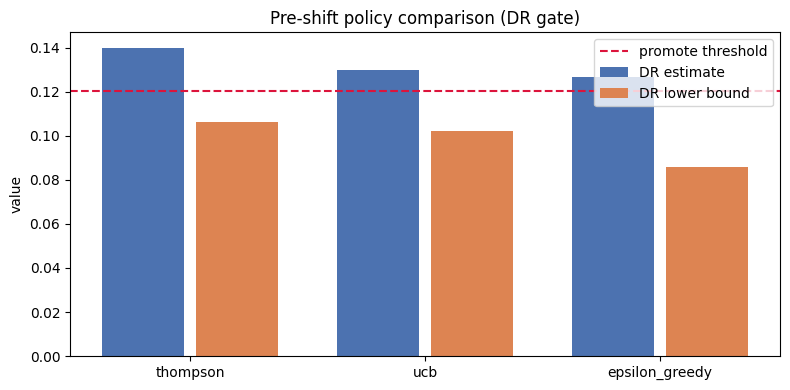

In [6]:
# Visual: DR point estimate vs conservative lower bound vs threshold
fig, ax = plt.subplots(figsize=(8, 4))
x = np.arange(len(df))
ax.bar(x - 0.2, df["DR"], width=0.35, label="DR estimate", color="#4C72B0")
ax.bar(x + 0.2, df["DR_lb"], width=0.35, label="DR lower bound", color="#DD8452")
ax.axhline(baseline + settings.ope_min_lift, color="crimson", ls="--", label="promote threshold")
ax.set_xticks(x)
ax.set_xticklabels(df["policy"])
ax.set_ylabel("value")
ax.set_title("Pre-shift policy comparison (DR gate)")
ax.legend()
plt.tight_layout()
plt.show()


## Part D — Timeline: what happens when

```text
BEFORE SHIFT (offline, run_demo steps 1–4)
  generate logs → train q(x,a) → build policies → OPE/DR gate → pick winner

START OF SHIFT (you propose doors)
  my_doors = [...]           ← territory manager / CRM
  route = plan_route(my_doors)   ← router (TSP-P)

DURING SHIFT (door by door)
  for door in route:
      action, p = recommend(door)   ← bandit (+ ethics cap)
      ... rep acts ...
      feedback(decision_id, outcome)

PERIODICALLY
  route = replan(remaining)       ← optional re-solve
```

The DR gate never runs at the door — it ran **once** before deployment. Propensity logging at each door
is what makes the *next* DR gate possible.
